## 0. Instalación e importación de librerías

In [1]:
# ── Instalar paquetes (solo la primera vez) ──────────────
paquetes <- c("tidyverse", "ggplot2", "corrplot",
              "gridExtra", "scales", "GGally", "reshape2")
nuevos <- paquetes[!(paquetes %in% installed.packages()[,"Package"])]
if (length(nuevos) > 0) install.packages(nuevos, quiet = TRUE)

library(tidyverse)
library(ggplot2)
library(corrplot)
library(gridExtra)
library(scales)
library(GGally)

options(scipen = 999, digits = 3)
cat("✅ Librerías cargadas correctamente\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




✅ Librerías cargadas correctamente


## 1. Carga del dataset

In [2]:
# ── Opción A: subir archivo manualmente ───────────────────
# Ejecuta esta línea para abrir el selector de archivos en Colab:
# file <- file.choose()
# df   <- read.csv(file, stringsAsFactors = TRUE)

# ── Opción B: cargar directamente si ya está en el entorno ─
df <- read.csv("/content/Train bank.csv", stringsAsFactors = TRUE)

cat("Dimensiones:", nrow(df), "filas x", ncol(df), "columnas\n")
head(df)

Dimensiones: 31648 filas x 18 columnas


,X,Age,Job,Marital.Status,Education,Credit,Balance..euros.,Housing.Loan,Personal.Loan,Contact,Last.Contact.Day,Last.Contact.Month,Last.Contact.Duration,Campaign,Pdays,Previous,Poutcome,Subscription
,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<int>,<int>,<fct>,<int>
1,1,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
2,2,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
3,3,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
4,4,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
5,6,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,0
6,7,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,0


## 2. Inspección inicial

In [3]:
str(df)

'data.frame':	31648 obs. of  18 variables:
 $ X                    : int  1 2 3 4 6 7 8 9 10 13 ...
 $ Age                  : int  58 44 33 47 35 28 42 58 43 53 ...
 $ Job                  : Factor w/ 12 levels "admin.","blue-collar",..: 5 10 3 2 5 5 3 6 10 10 ...
 $ Marital.Status       : Factor w/ 3 levels "divorced","married",..: 2 3 2 2 2 3 1 2 3 2 ...
 $ Education            : Factor w/ 4 levels "primary","secondary",..: 3 2 2 4 3 3 3 1 2 2 ...
 $ Credit               : Factor w/ 2 levels "no","yes": 1 1 1 1 1 1 2 1 1 1 ...
 $ Balance..euros.      : int  2143 29 2 1506 231 447 2 121 593 6 ...
 $ Housing.Loan         : Factor w/ 2 levels "no","yes": 2 2 2 2 2 2 2 2 2 2 ...
 $ Personal.Loan        : Factor w/ 2 levels "no","yes": 1 1 2 1 1 2 1 1 1 1 ...
 $ Contact              : Factor w/ 3 levels "cellular","telephone",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ Last.Contact.Day     : int  5 5 5 5 5 5 5 5 5 5 ...
 $ Last.Contact.Month   : Factor w/ 12 levels "apr","aug","dec",..: 9 9 9 9 9 9 9 

In [4]:
cat_cols      <- names(df)[sapply(df, is.factor)]
num_cols      <- names(df)[sapply(df, is.numeric)]
num_cols_feat <- num_cols[!num_cols %in% c("Subscription", "X", "Unnamed..0")]

cat_cols_sin_y <- cat_cols[cat_cols != "Subscription"]

cat("Categóricas (", length(cat_cols), "):", cat_cols, "\n")
cat("Numéricas sin target (", length(num_cols_feat), "):", num_cols_feat, "\n")

Categóricas ( 9 ): Job Marital.Status Education Credit Housing.Loan Personal.Loan Contact Last.Contact.Month Poutcome 
Numéricas sin target ( 7 ): Age Balance..euros. Last.Contact.Day Last.Contact.Duration Campaign Pdays Previous 


## 3. Valores faltantes

In [5]:
missing_df <- data.frame(
  Variable   = names(df),
  Faltantes  = colSums(is.na(df)),
  Porcentaje = round(colSums(is.na(df)) / nrow(df) * 100, 2)
)
missing_df <- missing_df[missing_df$Faltantes > 0, ]

if (nrow(missing_df) == 0) {
  cat("✅ Sin valores faltantes en el dataset\n")
} else {
  print(missing_df)
}

✅ Sin valores faltantes en el dataset


## 4. Análisis de la variable objetivo: y

In [6]:
conteo <- table(df$y)
pct    <- prop.table(conteo) * 100

cat("=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===\n")
print(data.frame(
  Conteo     = as.integer(conteo),
  Porcentaje = round(as.numeric(pct), 2),
  row.names  = names(conteo)
))
cat(sprintf("\nTasa de conversión global: %.2f%%\n", as.numeric(pct["yes"])))

=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===
[1] Conteo     Porcentaje
<0 rows> (or 0-length row.names)

Tasa de conversión global: NA%


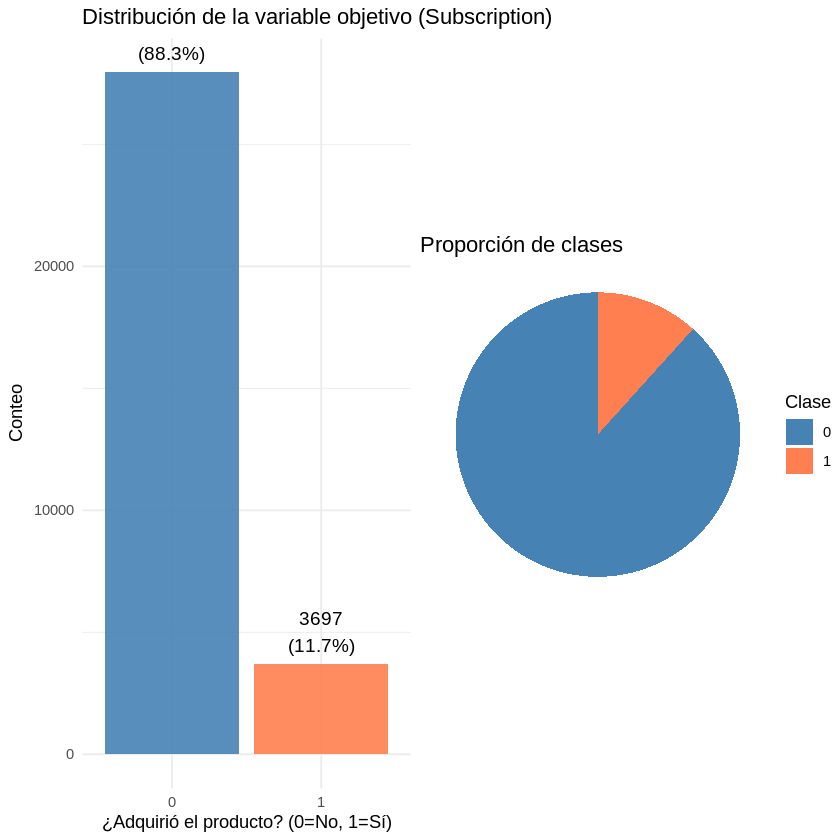

In [7]:
conteo  <- table(df$Subscription)
pct     <- prop.table(conteo) * 100
pct_vec <- round(as.numeric(pct), 1)

df_y <- data.frame(
  Clase  = factor(names(conteo)),
  Conteo = as.integer(conteo)
)

p1 <- ggplot(df_y, aes(x = Clase, y = Conteo, fill = Clase)) +
  geom_bar(stat = "identity", alpha = 0.9) +
  geom_text(aes(label = paste0(Conteo, "\n(", pct_vec, "%)")),
            vjust = -0.3, size = 4) +
  scale_fill_manual(values = c("0" = "steelblue", "1" = "coral")) +
  labs(title = "Distribución de la variable objetivo (Subscription)",
       x = "¿Adquirió el producto? (0=No, 1=Sí)", y = "Conteo") +
  theme_minimal() + theme(legend.position = "none")

p2 <- ggplot(df_y, aes(x = "", y = Conteo, fill = Clase)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y") +
  scale_fill_manual(values = c("0" = "steelblue", "1" = "coral")) +
  labs(title = "Proporción de clases") +
  theme_void()

grid.arrange(p1, p2, ncol = 2)

## 5. Estadísticas descriptivas

In [8]:
vars_num <- df[, num_cols_feat]
cat("=== ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS ===\n")
summary(vars_num)

=== ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS ===


      Age       Balance..euros.  Last.Contact.Day Last.Contact.Duration
 Min.   :18.0   Min.   : -8019   Min.   : 1.0     Min.   :   0         
 1st Qu.:33.0   1st Qu.:    72   1st Qu.: 8.0     1st Qu.: 103         
 Median :39.0   Median :   452   Median :16.0     Median : 179         
 Mean   :40.9   Mean   :  1377   Mean   :15.8     Mean   : 257         
 3rd Qu.:48.0   3rd Qu.:  1438   3rd Qu.:21.0     3rd Qu.: 317         
 Max.   :95.0   Max.   :102127   Max.   :31.0     Max.   :3422         
    Campaign         Pdays          Previous      
 Min.   : 1.00   Min.   : -1.0   Min.   :  0.000  
 1st Qu.: 1.00   1st Qu.: -1.0   1st Qu.:  0.000  
 Median : 2.00   Median : -1.0   Median :  0.000  
 Mean   : 2.76   Mean   : 39.9   Mean   :  0.586  
 3rd Qu.: 3.00   3rd Qu.: -1.0   3rd Qu.:  0.000  
 Max.   :63.00   Max.   :871.0   Max.   :275.000  

In [9]:
# Media y mediana
desc <- data.frame(
  Variable = num_cols_feat,
  Media    = sapply(vars_num, mean,   na.rm = TRUE),
  Mediana  = sapply(vars_num, median, na.rm = TRUE)
)
desc[, c("Media","Mediana")] <- round(desc[, c("Media","Mediana")], 3)
rownames(desc) <- NULL
print(desc)

               Variable    Media Mediana
1                   Age   40.929      39
2       Balance..euros. 1377.339     452
3      Last.Contact.Day   15.806      16
4 Last.Contact.Duration  256.752     179
5              Campaign    2.762       2
6                 Pdays   39.935      -1
7              Previous    0.586       0


In [10]:
cat("=== ESTADÍSTICAS — VARIABLES CATEGÓRICAS ===\n")
for (col in cat_cols_sin_y) {
  cat("\n──", col, "──\n")
  print(table(df[[col]]))
}

=== ESTADÍSTICAS — VARIABLES CATEGÓRICAS ===

── Job ──

       admin.   blue-collar  entrepreneur     housemaid    management 
         3592          6763          1067           868          6594 
      retired self-employed      services       student    technician 
         1604          1125          2951           671          5278 
   unemployed       unknown 
          932           203 

── Marital.Status ──

divorced  married   single 
    3619    19027     9002 

── Education ──

  primary secondary  tertiary   unknown 
     4838     16118      9386      1306 

── Credit ──

   no   yes 
31065   583 

── Housing.Loan ──

   no   yes 
14175 17473 

── Personal.Loan ──

   no   yes 
26559  5089 

── Contact ──

 cellular telephone   unknown 
    20497      2021      9130 

── Last.Contact.Month ──

 apr  aug  dec  feb  jan  jul  jun  mar  may  nov  oct  sep 
2040 4431  155 1863  959 4838 3747  330 9582 2787  519  397 

── Poutcome ──

failure   other success unknown 
   3435  

## 6. Distribución de variables numéricas

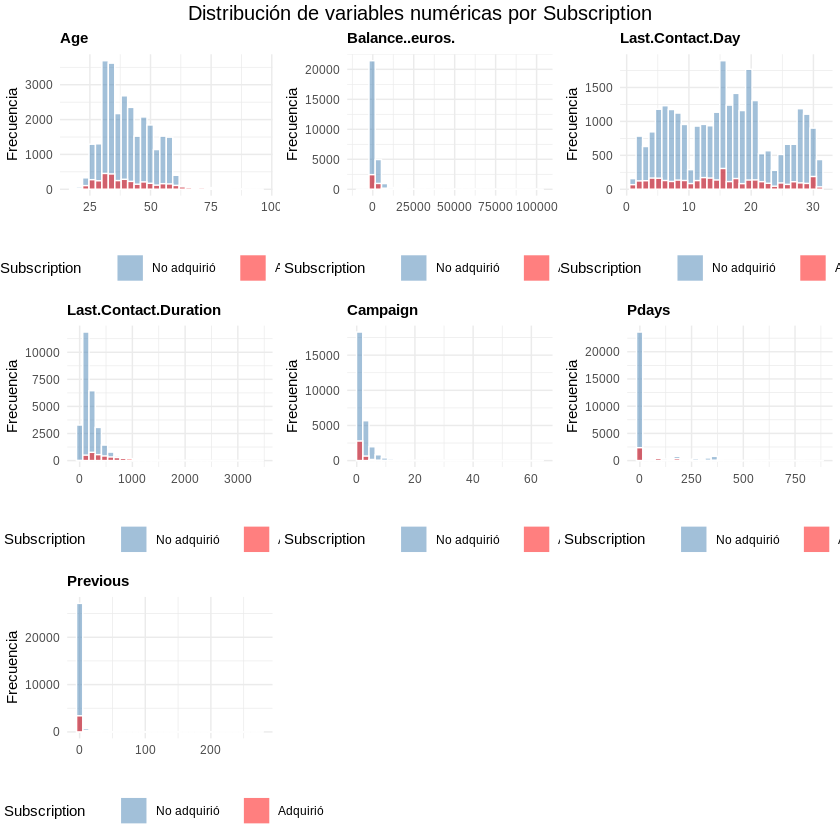

In [18]:
plots_hist <- lapply(num_cols_feat, function(col) {

  ggplot(df,
         aes_string(x = col,
                    fill = "factor(Subscription)")) +

    geom_histogram(
      bins = 30,
      color = "white",
      alpha = 0.5,
      position = "identity"
    ) +

    scale_fill_manual(
      values = c(
        "0" = "steelblue",
        "1" = "red"
      ),
      labels = c(
        "0" = "No adquirió",
        "1" = "Adquirió"
      )
    ) +

    labs(
      title = col,
      x = "",
      y = "Frecuencia",
      fill = "Subscription"
    ) +

    theme_minimal(base_size = 9) +

    theme(
      plot.title = element_text(
        size = 9,
        face = "bold"
      ),
      legend.position = "bottom"
    )
})

do.call(
  grid.arrange,
  c(
    plots_hist,
    ncol = 3,
    top = "Distribución de variables numéricas por Subscription"
  )
)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


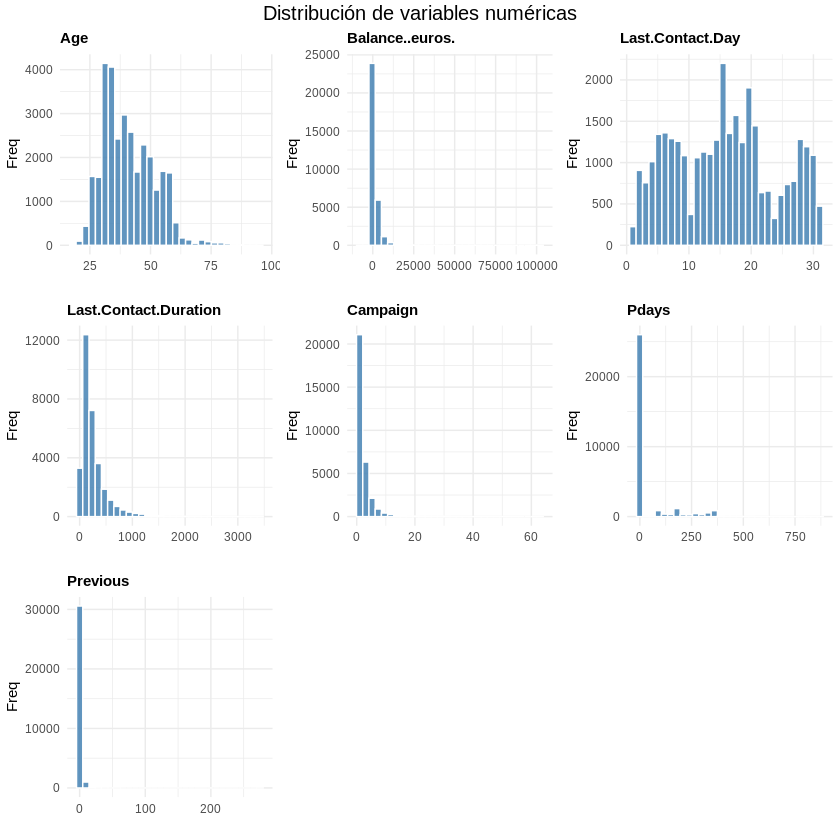

In [11]:
plots_hist <- lapply(num_cols_feat, function(col) {
  ggplot(df, aes_string(x = col)) +
    geom_histogram(bins = 30, fill = "steelblue",
                   color = "white", alpha = 0.85) +
    labs(title = col, x = "", y = "Freq") +
    theme_minimal(base_size = 9) +
    theme(plot.title = element_text(size = 9, face = "bold"))
})

do.call(grid.arrange, c(plots_hist, ncol = 3,
  top = "Distribución de variables numéricas"))

## 7. Variables numéricas por clase (y)

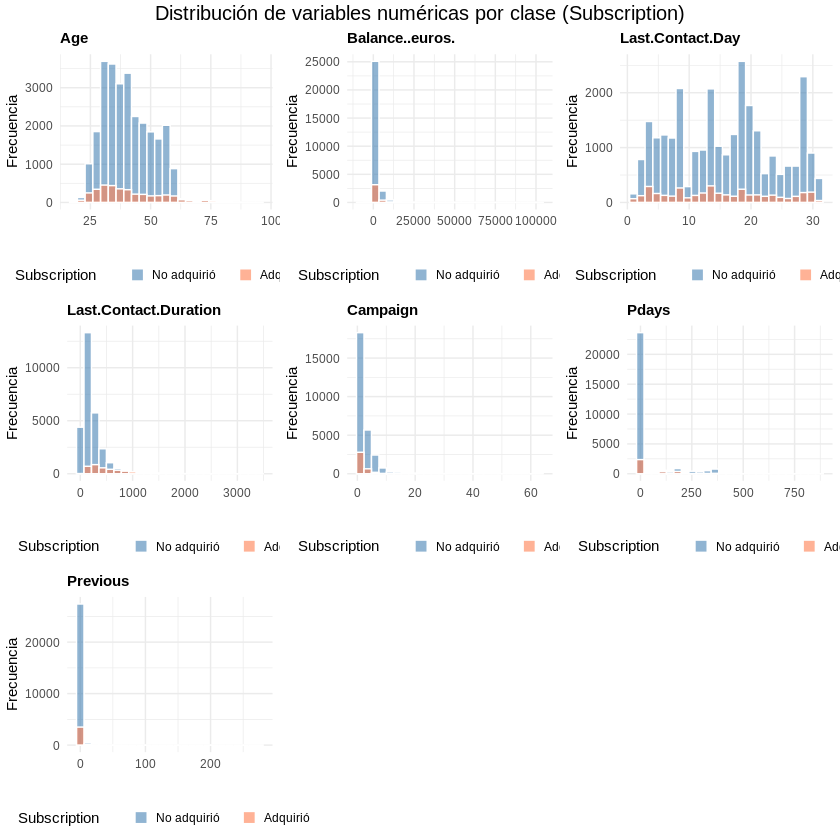

In [12]:
plots_clase <- lapply(num_cols_feat, function(col) {

  ggplot(df, aes_string(x = col, fill = "factor(Subscription)")) +

    geom_histogram(
      bins = 25,
      alpha = 0.6,
      color = "white",
      position = "identity"
    ) +

    scale_fill_manual(
      values = c(
        "0" = "steelblue",
        "1" = "coral"
      ),
      labels = c(
        "0" = "No adquirió",
        "1" = "Adquirió"
      )
    ) +

    labs(
      title = col,
      x = "",
      y = "Frecuencia",
      fill = "Subscription"
    ) +

    theme_minimal(base_size = 9) +

    theme(
      legend.position = "bottom",
      legend.key.size = unit(0.3, "cm"),
      plot.title = element_text(size = 9, face = "bold")
    )
})

do.call(
  grid.arrange,
  c(
    plots_clase,
    ncol = 3,
    top = "Distribución de variables numéricas por clase (Subscription)"
  )
)

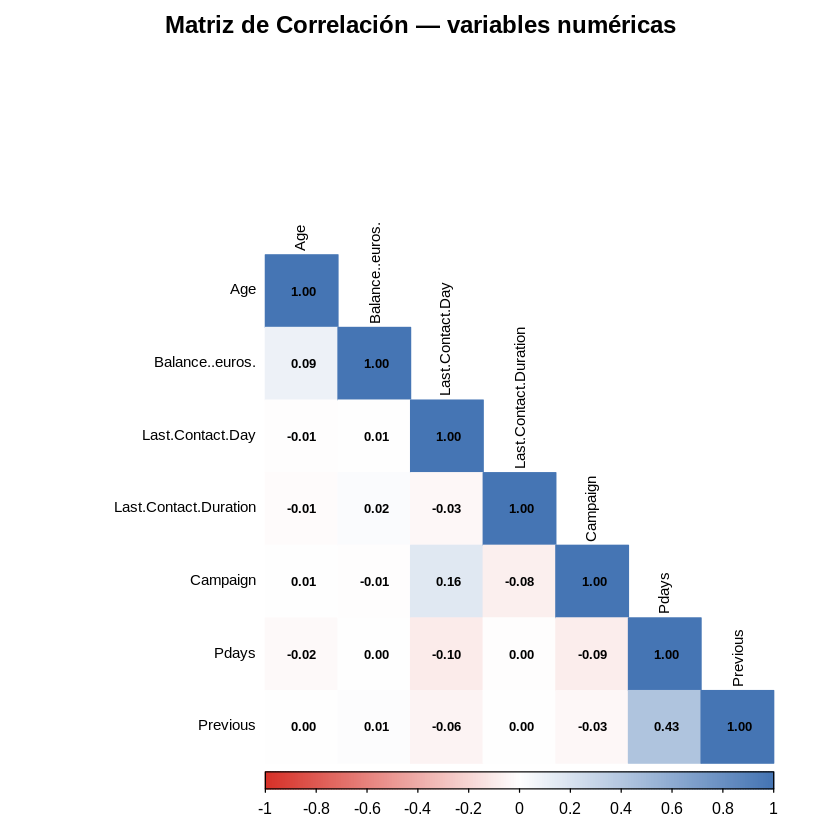

In [13]:
# ── Matriz de correlación ─────────────────────────────────
vars_num   <- df[, num_cols_feat]
corr_matrix <- cor(vars_num, use = "complete.obs")

corrplot(corr_matrix,
         method      = "color",
         type        = "lower",
         addCoef.col = "black",
         number.cex  = 0.65,
         tl.cex      = 0.75,
         tl.col      = "black",
         col         = colorRampPalette(c("#d73027","white","#4575b4"))(200),
         title       = "Matriz de Correlación — variables numéricas",
         mar         = c(0, 0, 2, 0))

## 8. Boxplots de variables numéricas por clase

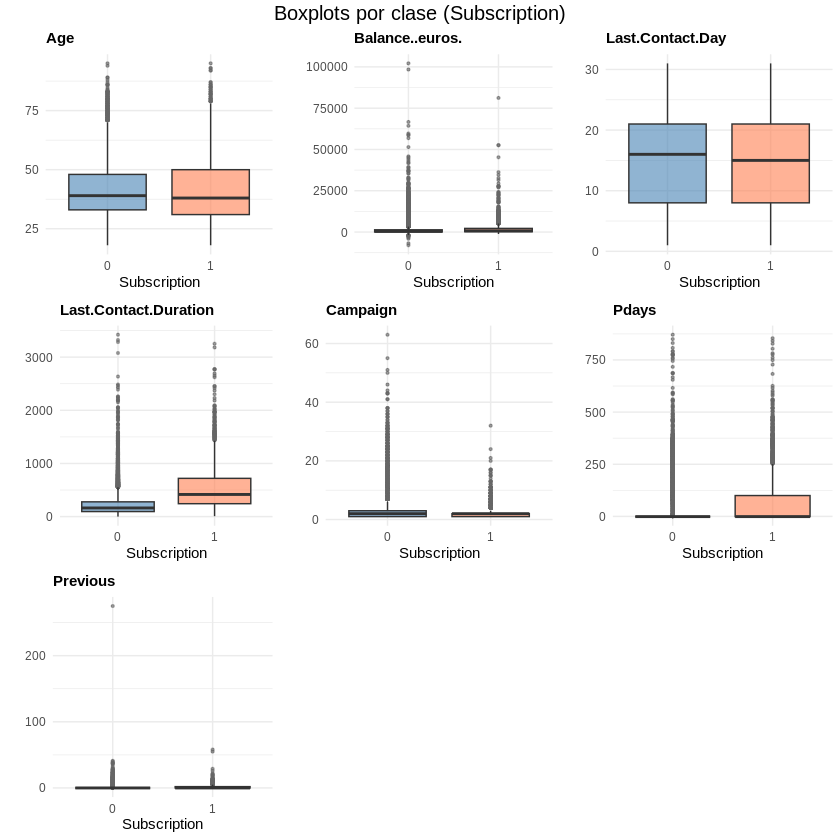

In [14]:
plots_box <- lapply(num_cols_feat, function(col) {

  ggplot(df,
         aes(
           x = factor(Subscription),
           y = .data[[col]],
           fill = factor(Subscription)
         )) +

    geom_boxplot(
      alpha = 0.6,
      outlier.color = "gray40",
      outlier.size = 0.5
    ) +

    scale_fill_manual(
      values = c(
        "0" = "steelblue",
        "1" = "coral"
      )
    ) +

    labs(
      title = col,
      x = "Subscription",
      y = ""
    ) +

    theme_minimal(base_size = 9) +

    theme(
      legend.position = "none",
      plot.title = element_text(size = 9, face = "bold")
    )
})

grid.arrange(
  grobs = plots_box,
  ncol = 3,
  top = "Boxplots por clase (Subscription)"
)

## 9. Variables categóricas — frecuencias y tasa de conversión

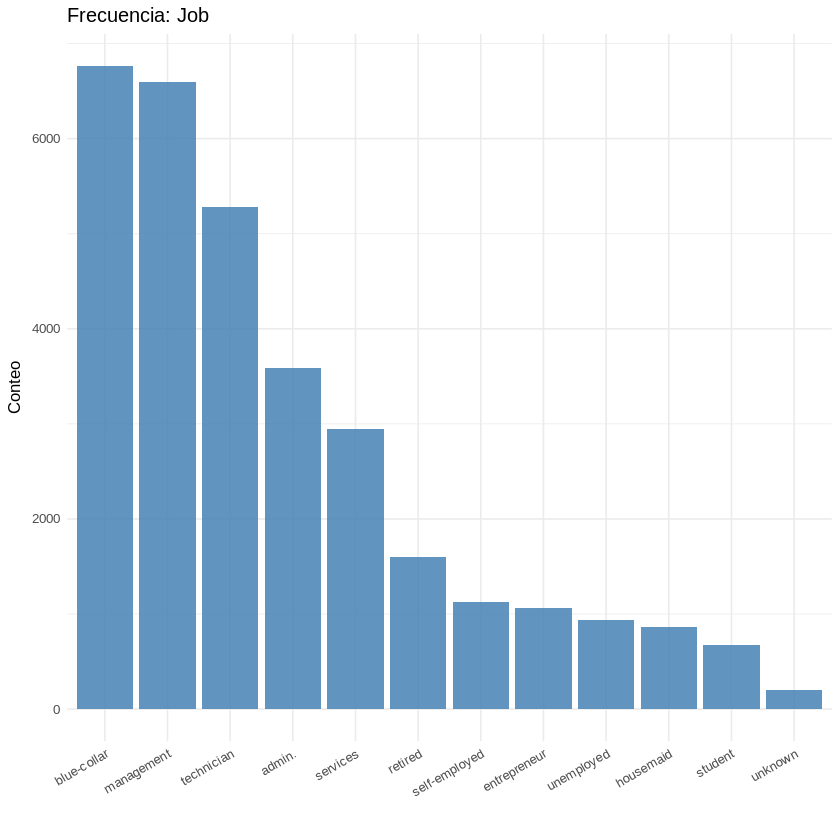

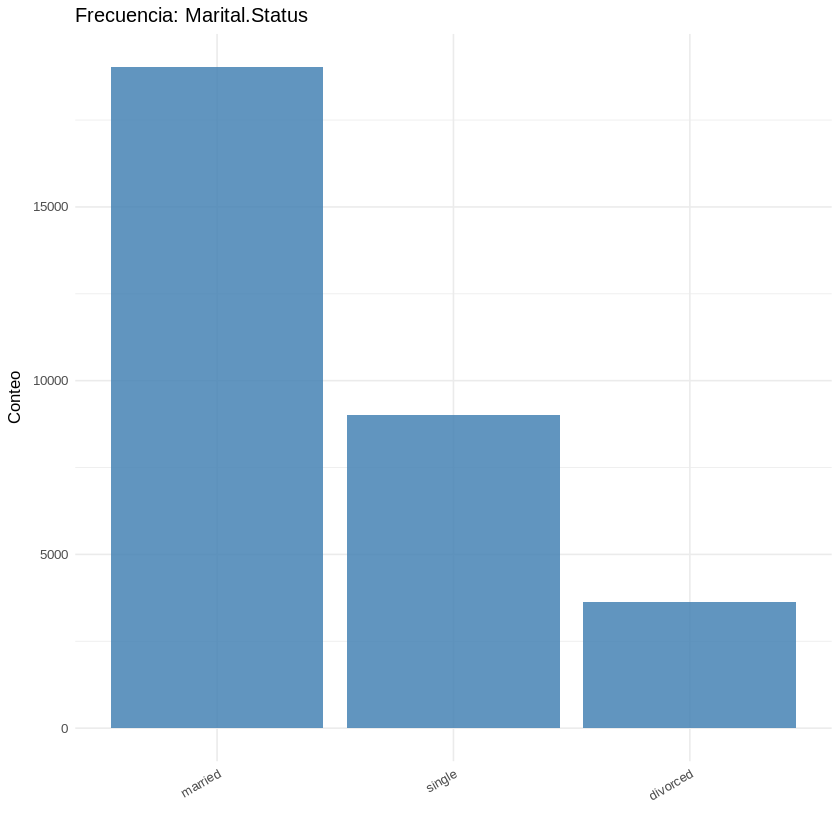

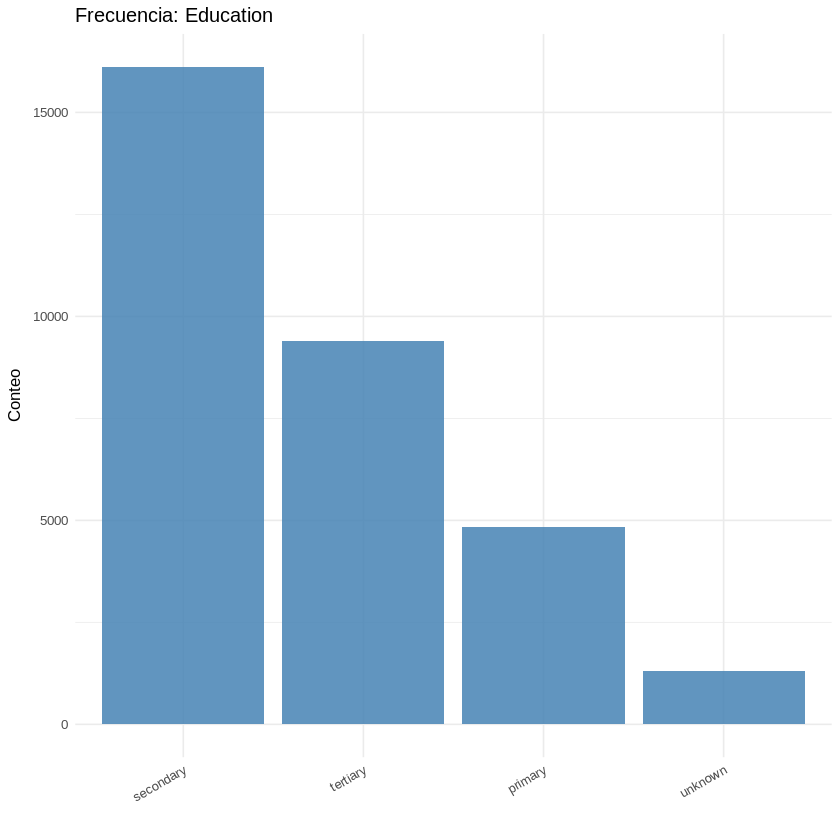

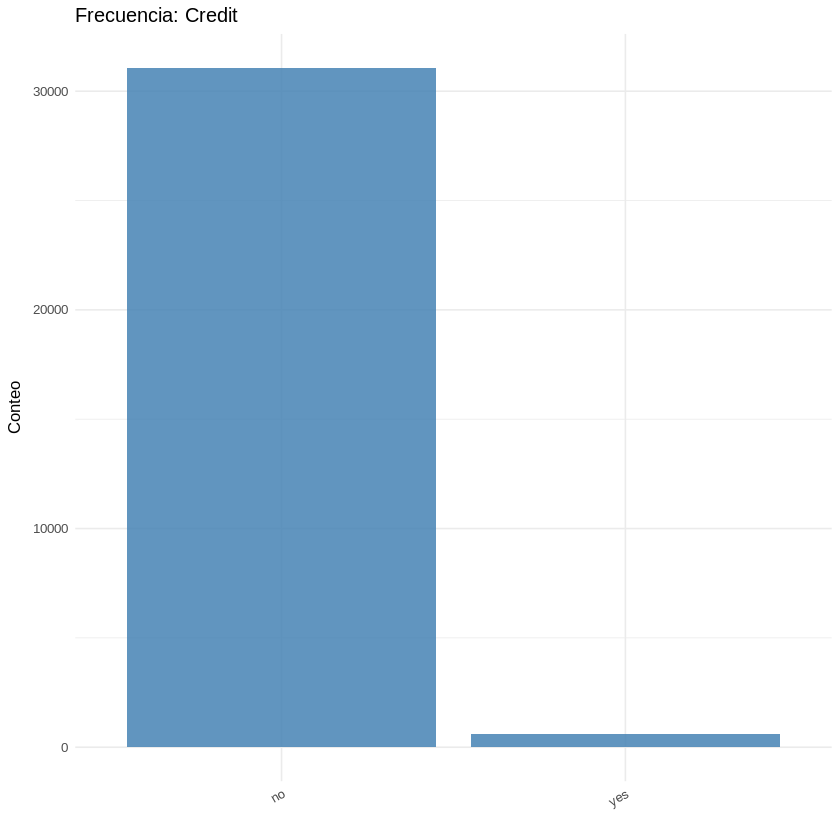

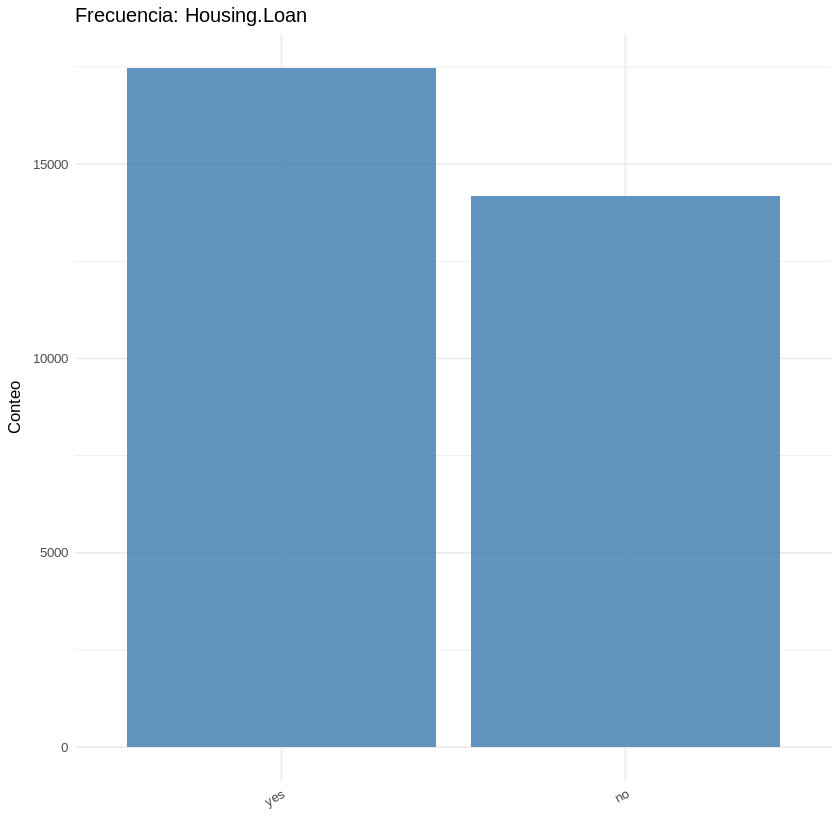

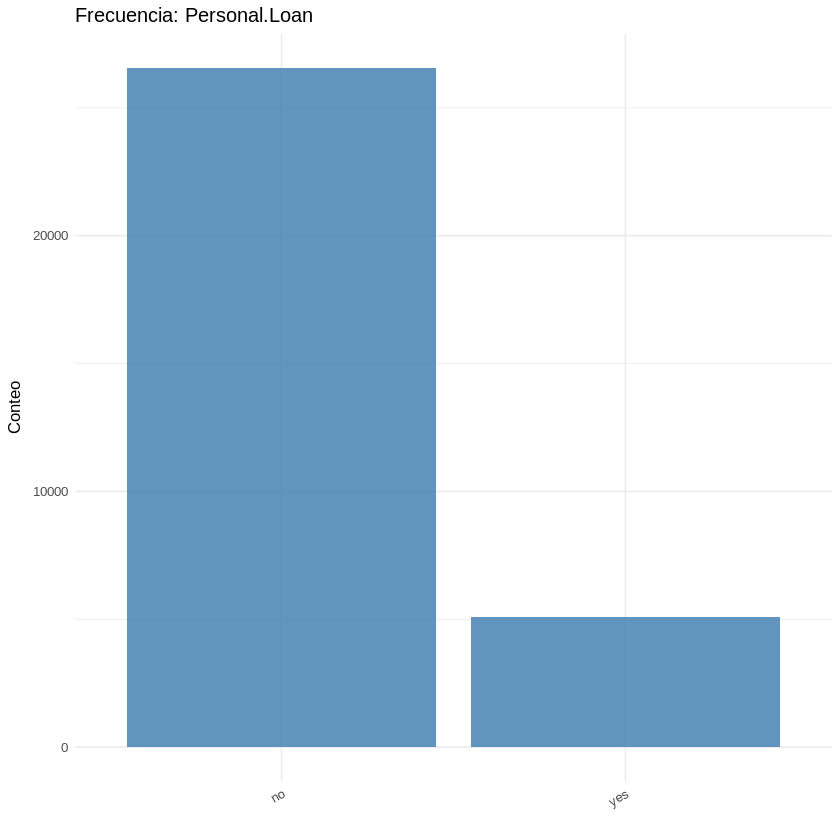

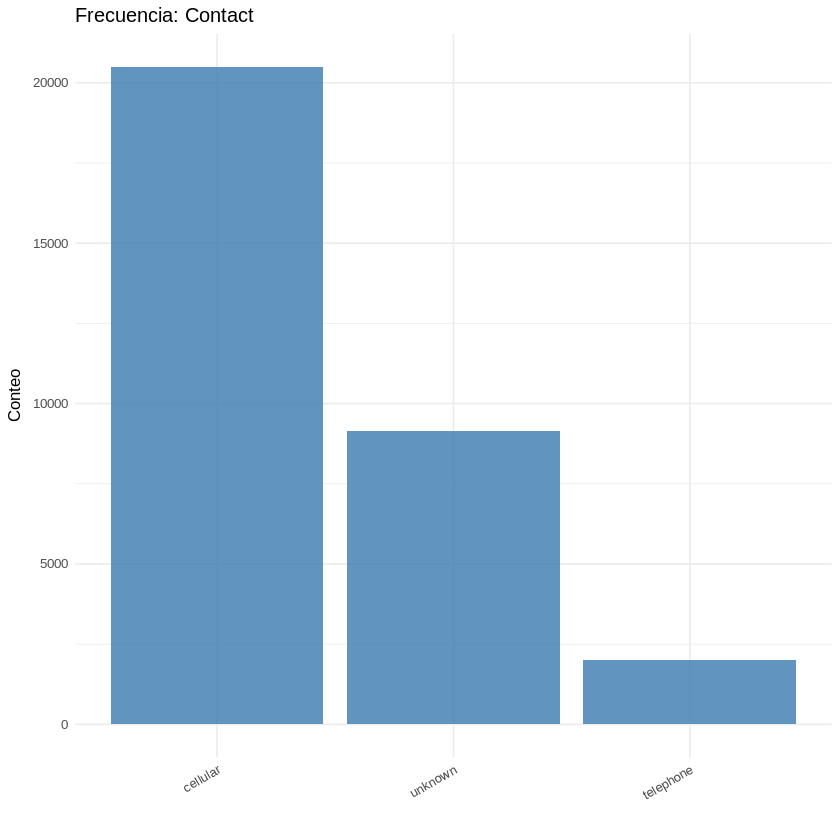

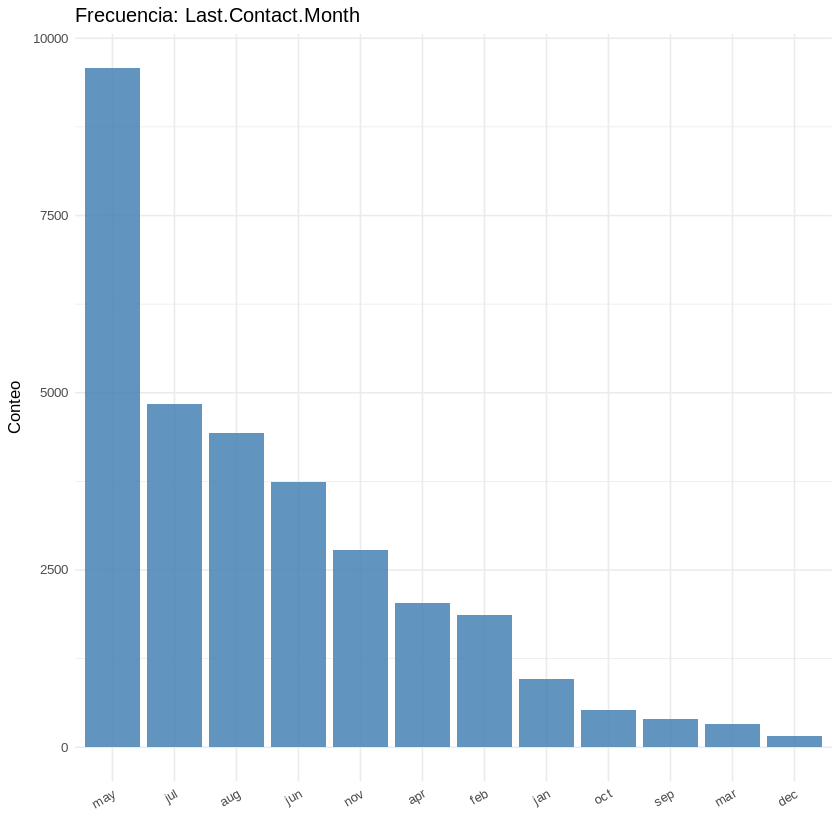

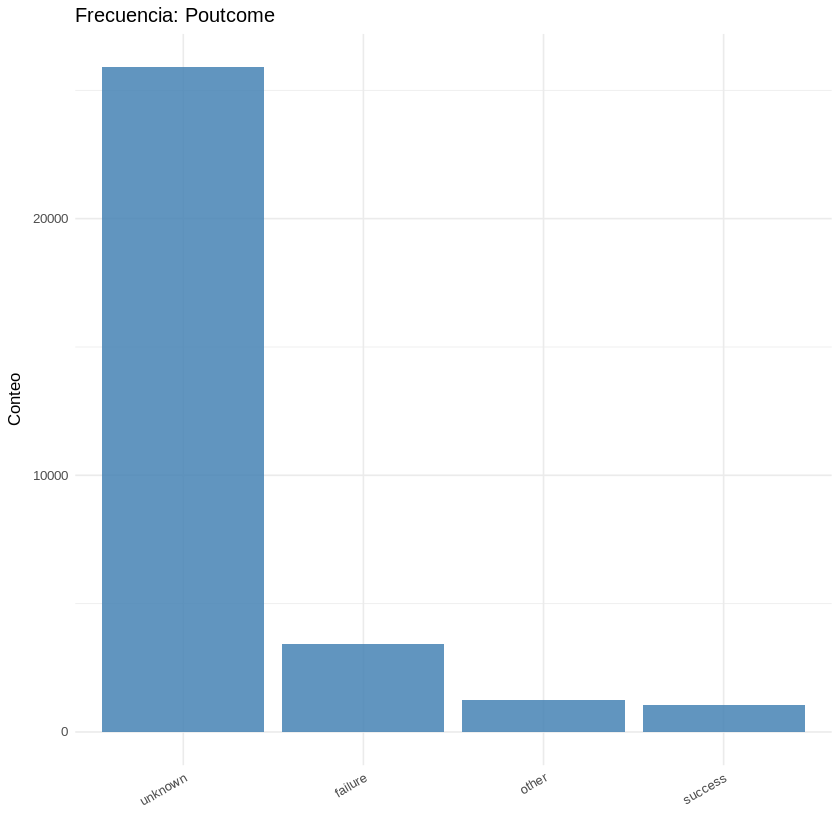

In [15]:
for (col in cat_cols_sin_y) {

  freq_df <- as.data.frame(table(df[[col]]))
  names(freq_df) <- c("Categoria", "Frecuencia")

  p_bar <- ggplot(
    freq_df,
    aes(
      x = reorder(Categoria, -Frecuencia),
      y = Frecuencia
    )
  ) +
    geom_bar(
      stat = "identity",
      fill = "steelblue",
      alpha = 0.85
    ) +
    labs(
      title = paste("Frecuencia:", col),
      x = "",
      y = "Conteo"
    ) +
    theme_minimal(base_size = 10) +
    theme(
      axis.text.x = element_text(
        angle = 30,
        hjust = 1
      )
    )

  print(p_bar)
}

## 10. Correlación entre variables numéricas

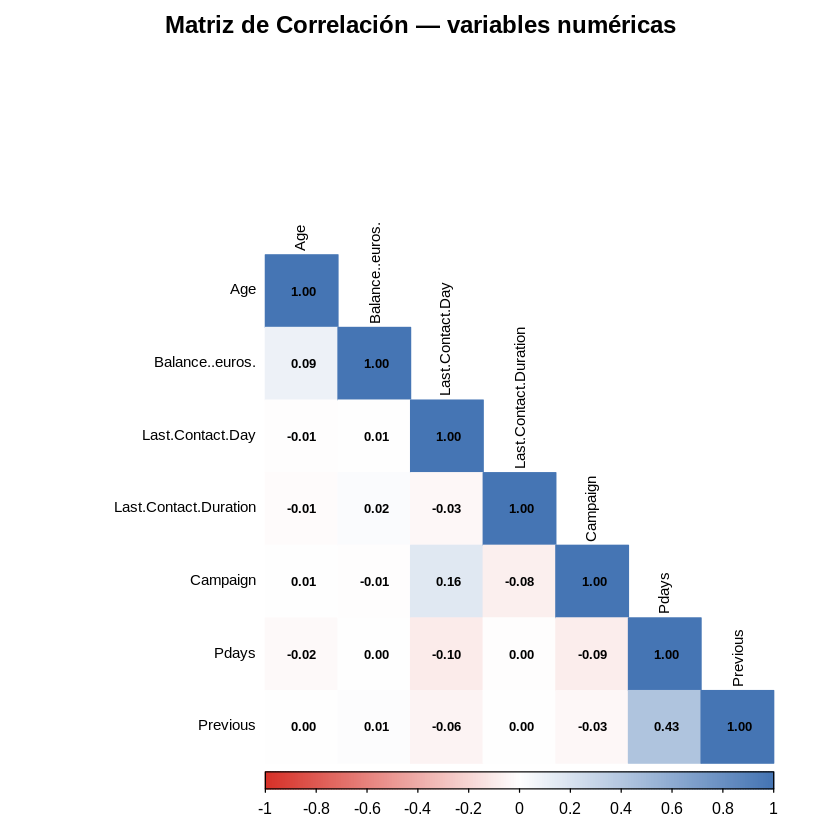

In [16]:
corr_matrix <- cor(vars_num, use = "complete.obs")

corrplot(corr_matrix,
         method      = "color",
         type        = "lower",
         addCoef.col = "black",
         number.cex  = 0.65,
         tl.cex      = 0.75,
         tl.col      = "black",
         col         = colorRampPalette(c("#d73027","white","#4575b4"))(200),
         title       = "Matriz de Correlación — variables numéricas",
         mar         = c(0, 0, 2, 0))

## 15. Resumen final — R

In [17]:
tasa_global <- mean(df$y == "yes") * 100

cat(strrep("=", 55), "\n")
cat("     RESUMEN DE LA EXPLORACIÓN — MARKETING BANCARIO\n")
cat(strrep("=", 55), "\n")
cat(sprintf("  Observaciones:          %d\n",   nrow(df)))
cat(sprintf("  Variables totales:      %d\n",   ncol(df)))
cat(sprintf("  Variables numéricas:    %d\n",   length(num_cols_feat)))
cat(sprintf("  Variables categóricas:  %d\n",   length(cat_cols_sin_y)))
cat(sprintf("  Columnas con nulos:     %d\n",   sum(colSums(is.na(df)) > 0)))
cat(sprintf("  Tasa de conversión:     %.2f%%  ← desbalance de clases\n", tasa_global))
cat(sprintf("  Duración media llamada: %.0f seg\n", mean(df$Last.Contact.Duration)))
cat(sprintf("  Campañas promedio:      %.2f\n", mean(df$Campaign)))
cat(strrep("=", 55), "\n")

     RESUMEN DE LA EXPLORACIÓN — MARKETING BANCARIO
  Observaciones:          31648
  Variables totales:      18
  Variables numéricas:    7
  Variables categóricas:  9
  Columnas con nulos:     0
  Tasa de conversión:     NaN%  ← desbalance de clases
  Duración media llamada: 257 seg
  Campañas promedio:      2.76
